In [5]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
import en_core_web_sm

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download('stopwords')

from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

nlp = en_core_web_sm.load()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lavan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [2]:
import sys
print(sys.executable)

C:\Users\lavan\anaconda3\python.exe


In [3]:
import spacy
print(spacy.__version__)

3.8.14


In [4]:
import en_core_web_sm

nlp = en_core_web_sm.load()
print("Model loaded successfully!")

Model loaded successfully!


In [12]:
import os

print(os.listdir("data"))

['job_description.txt', 'resumes.csv']


In [13]:
import pandas as pd

df = pd.read_csv("data/resumes.csv")
df.head()

,ID,Resume_str,Resume_html,Category
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR


In [14]:
print(df.columns)

Index(['ID', 'Resume_str', 'Resume_html', 'Category'], dtype='object')


In [15]:
import re

def clean_resume(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z ]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

df["Clean_Resume"] = df["Resume_str"].apply(clean_resume)

df[["Resume_str", "Clean_Resume"]].head()

,Resume_str,Clean_Resume
0,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,hr administrator marketing associate hr admini...
1,"HR SPECIALIST, US HR OPERATIONS ...",hr specialist us hr operations summary versati...
2,HR DIRECTOR Summary Over 2...,hr director summary over years experience in r...
3,HR SPECIALIST Summary Dedica...,hr specialist summary dedicated driven and dyn...
4,HR MANAGER Skill Highlights ...,hr manager skill highlights hr skills hr depar...


In [16]:
with open("data/job_description.txt", "r", encoding="utf-8") as f:
    job_description = f.read()

print(job_description)

Python Machine Learning Developer

Required Skills:
- Python
- Machine Learning
- Pandas
- NumPy
- Scikit-learn
- SQL
- Git
- Data Analysis
- Natural Language Processing (NLP)
- Communication
- Problem Solving


In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [job_description] + df["Clean_Resume"].tolist()

vectorizer = TfidfVectorizer(stop_words='english')

tfidf_matrix = vectorizer.fit_transform(documents)

print(tfidf_matrix.shape)

(2485, 37266)


In [18]:
from sklearn.metrics.pairwise import cosine_similarity

job_vector = tfidf_matrix[0]

resume_vectors = tfidf_matrix[1:]

similarity_scores = cosine_similarity(job_vector, resume_vectors)

df["Score"] = similarity_scores.flatten()

df.head()

,ID,Resume_str,Resume_html,Category,Clean_Resume,Score
0,16852973,HR ADMINISTRATOR/MARKETING ASSOCIATE\...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr administrator marketing associate hr admini...,0.009772
1,22323967,"HR SPECIALIST, US HR OPERATIONS ...","<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist us hr operations summary versati...,0.006220
2,33176873,HR DIRECTOR Summary Over 2...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr director summary over years experience in r...,0.004712
3,27018550,HR SPECIALIST Summary Dedica...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr specialist summary dedicated driven and dyn...,0.004035
4,17812897,HR MANAGER Skill Highlights ...,"<div class=""fontsize fontface vmargins hmargin...",HR,hr manager skill highlights hr skills hr depar...,0.006290


In [19]:
ranked_df = df.sort_values(by="Score", ascending=False)

ranked_df.head(10)

,ID,Resume_str,Resume_html,Category,Clean_Resume,Score
926,62994611,SOFTWARE DEVELOPER Professi...,"<div class=""MPR skn-cbg1 fontsize fontface vma...",AGRICULTURE,software developer professional summary enthus...,0.198327
1339,18448085,DATA ANALYST Professional Summa...,"<div class=""fontsize fontface vmargins hmargin...",AUTOMOBILE,data analyst professional summary industrial a...,0.184523
1762,12011623,ENGINEERING AND QUALITY TECHNICIAN ...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING,engineering and quality technician career over...,0.169025
2153,34953092,"CORPORATE BANKING ASSISTANT, INTERN ...","<div class=""fontsize fontface vmargins hmargin...",BANKING,corporate banking assistant intern objective d...,0.144809
1218,21156767,Pavithra Shetty Summary ...,"<div class=""RNA skn-mlf9 fontsize fontface vma...",CONSULTANT,pavithra shetty summary customer oriented prin...,0.128093
1348,22946204,Highlights Prog. Languages: ...,"<div class=""fontsize fontface vmargins hmargin...",AUTOMOBILE,highlights prog languages c yrs python yrs jav...,0.120283
2291,12777487,ONLINE LEARNING COORDINATOR - PROGRAM...,"<div class=""fontsize fontface vmargins hmargin...",ARTS,online learning coordinator program training a...,0.116286
1750,27152464,QA ENGINEERING MANAGER Prof...,"<div class=""LCA skn-cbg1 fontsize fontface vma...",ENGINEERING,qa engineering manager professional summary se...,0.107257
2395,12144825,SOFTWARE ENGINEERING CO-OP Summ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,software engineering co op summary highly skil...,0.101450
1303,42156237,SENIOR DIGITAL MARKETING ANALYST ...,"<div class=""fontsize fontface vmargins hmargin...",DIGITAL-MEDIA,senior digital marketing analyst summary highl...,0.100334


In [20]:
import os

os.makedirs("output", exist_ok=True)

ranked_df.to_csv("output/ranked_candidates.csv", index=False)

print("Output saved successfully!")

Output saved successfully!


In [21]:
skills = [
    "python",
    "machine learning",
    "pandas",
    "numpy",
    "scikit-learn",
    "sql",
    "git",
    "data analysis",
    "natural language processing",
    "communication",
    "problem solving"
]

def missing_skills(resume):
    resume = resume.lower()
    missing = []

    for skill in skills:
        if skill.lower() not in resume:
            missing.append(skill)

    return ", ".join(missing)

ranked_df["Missing Skills"] = ranked_df["Clean_Resume"].apply(missing_skills)

ranked_df[["Category", "Score", "Missing Skills"]].head(10)

,Category,Score,Missing Skills
926,AGRICULTURE,0.198327,"machine learning, numpy, scikit-learn, git, da..."
1339,AUTOMOBILE,0.184523,"machine learning, scikit-learn, git, natural l..."
1762,ENGINEERING,0.169025,"numpy, scikit-learn, git, natural language pro..."
2153,BANKING,0.144809,"pandas, numpy, scikit-learn, git, data analysi..."
1218,CONSULTANT,0.128093,"pandas, numpy, scikit-learn, git, natural lang..."
1348,AUTOMOBILE,0.120283,"pandas, numpy, scikit-learn, git, natural lang..."
2291,ARTS,0.116286,"python, machine learning, pandas, numpy, sciki..."
1750,ENGINEERING,0.107257,"machine learning, pandas, numpy, scikit-learn,..."
2395,AVIATION,0.101450,"machine learning, pandas, numpy, scikit-learn,..."
1303,DIGITAL-MEDIA,0.100334,"machine learning, pandas, numpy, scikit-learn,..."


In [22]:
ranked_df.to_csv("output/ranked_candidates.csv", index=False)

print("Final output saved successfully!")

Final output saved successfully!


In [23]:
skills = [
    "python",
    "java",
    "c++",
    "sql",
    "machine learning",
    "deep learning",
    "data science",
    "artificial intelligence",
    "nlp",
    "tensorflow",
    "keras",
    "pytorch",
    "scikit-learn",
    "pandas",
    "numpy",
    "excel",
    "power bi",
    "tableau",
    "git",
    "github",
    "communication",
    "problem solving"
]

def extract_skills(text):
    text = text.lower()

    found = []

    for skill in skills:
        if skill in text:
            found.append(skill)

    return list(set(found))

ranked_df["Extracted Skills"] = ranked_df["Clean_Resume"].apply(extract_skills)

ranked_df.head()

,ID,Resume_str,Resume_html,Category,Clean_Resume,Score,Missing Skills,Extracted Skills
926,62994611,SOFTWARE DEVELOPER Professi...,"<div class=""MPR skn-cbg1 fontsize fontface vma...",AGRICULTURE,software developer professional summary enthus...,0.198327,"machine learning, numpy, scikit-learn, git, da...","[tensorflow, python, java, pandas, keras, tabl..."
1339,18448085,DATA ANALYST Professional Summa...,"<div class=""fontsize fontface vmargins hmargin...",AUTOMOBILE,data analyst professional summary industrial a...,0.184523,"machine learning, scikit-learn, git, natural l...","[python, pandas, problem solving, tableau, num..."
1762,12011623,ENGINEERING AND QUALITY TECHNICIAN ...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING,engineering and quality technician career over...,0.169025,"numpy, scikit-learn, git, natural language pro...","[python, pandas, tableau, machine learning, sq..."
2153,34953092,"CORPORATE BANKING ASSISTANT, INTERN ...","<div class=""fontsize fontface vmargins hmargin...",BANKING,corporate banking assistant intern objective d...,0.144809,"pandas, numpy, scikit-learn, git, data analysi...","[sql, python, machine learning]"
1218,21156767,Pavithra Shetty Summary ...,"<div class=""RNA skn-mlf9 fontsize fontface vma...",CONSULTANT,pavithra shetty summary customer oriented prin...,0.128093,"pandas, numpy, scikit-learn, git, natural lang...","[python, java, machine learning, data science,..."


In [24]:
job_skills = extract_skills(job_description)

print(job_skills)

['python', 'pandas', 'sql', 'problem solving', 'nlp', 'numpy', 'machine learning', 'scikit-learn', 'git', 'communication']


In [25]:
def find_missing(resume_skills):

    missing = []

    for skill in job_skills:

        if skill not in resume_skills:
            missing.append(skill)

    return missing

ranked_df["Missing Skills"] = ranked_df["Extracted Skills"].apply(find_missing)

ranked_df.head()

,ID,Resume_str,Resume_html,Category,Clean_Resume,Score,Missing Skills,Extracted Skills
926,62994611,SOFTWARE DEVELOPER Professi...,"<div class=""MPR skn-cbg1 fontsize fontface vma...",AGRICULTURE,software developer professional summary enthus...,0.198327,"[problem solving, nlp, numpy, machine learning...","[tensorflow, python, java, pandas, keras, tabl..."
1339,18448085,DATA ANALYST Professional Summa...,"<div class=""fontsize fontface vmargins hmargin...",AUTOMOBILE,data analyst professional summary industrial a...,0.184523,"[nlp, machine learning, scikit-learn, git, com...","[python, pandas, problem solving, tableau, num..."
1762,12011623,ENGINEERING AND QUALITY TECHNICIAN ...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING,engineering and quality technician career over...,0.169025,"[problem solving, nlp, numpy, scikit-learn, gi...","[python, pandas, tableau, machine learning, sq..."
2153,34953092,"CORPORATE BANKING ASSISTANT, INTERN ...","<div class=""fontsize fontface vmargins hmargin...",BANKING,corporate banking assistant intern objective d...,0.144809,"[pandas, problem solving, nlp, numpy, scikit-l...","[sql, python, machine learning]"
1218,21156767,Pavithra Shetty Summary ...,"<div class=""RNA skn-mlf9 fontsize fontface vma...",CONSULTANT,pavithra shetty summary customer oriented prin...,0.128093,"[pandas, problem solving, nlp, numpy, scikit-l...","[python, java, machine learning, data science,..."


In [26]:
def match_score(resume_skills):

    if len(job_skills) == 0:
        return 0

    matched = len(set(resume_skills) & set(job_skills))

    return round((matched / len(job_skills)) * 100, 2)

ranked_df["Match %"] = ranked_df["Extracted Skills"].apply(match_score)

ranked_df.head(10)

,ID,Resume_str,Resume_html,Category,Clean_Resume,Score,Missing Skills,Extracted Skills,Match %
926,62994611,SOFTWARE DEVELOPER Professi...,"<div class=""MPR skn-cbg1 fontsize fontface vma...",AGRICULTURE,software developer professional summary enthus...,0.198327,"[problem solving, nlp, numpy, machine learning...","[tensorflow, python, java, pandas, keras, tabl...",40.0
1339,18448085,DATA ANALYST Professional Summa...,"<div class=""fontsize fontface vmargins hmargin...",AUTOMOBILE,data analyst professional summary industrial a...,0.184523,"[nlp, machine learning, scikit-learn, git, com...","[python, pandas, problem solving, tableau, num...",50.0
1762,12011623,ENGINEERING AND QUALITY TECHNICIAN ...,"<div class=""fontsize fontface vmargins hmargin...",ENGINEERING,engineering and quality technician career over...,0.169025,"[problem solving, nlp, numpy, scikit-learn, gi...","[python, pandas, tableau, machine learning, sq...",40.0
2153,34953092,"CORPORATE BANKING ASSISTANT, INTERN ...","<div class=""fontsize fontface vmargins hmargin...",BANKING,corporate banking assistant intern objective d...,0.144809,"[pandas, problem solving, nlp, numpy, scikit-l...","[sql, python, machine learning]",30.0
1218,21156767,Pavithra Shetty Summary ...,"<div class=""RNA skn-mlf9 fontsize fontface vma...",CONSULTANT,pavithra shetty summary customer oriented prin...,0.128093,"[pandas, problem solving, nlp, numpy, scikit-l...","[python, java, machine learning, data science,...",30.0
1348,22946204,Highlights Prog. Languages: ...,"<div class=""fontsize fontface vmargins hmargin...",AUTOMOBILE,highlights prog languages c yrs python yrs jav...,0.120283,"[pandas, problem solving, nlp, numpy, scikit-l...","[python, java, machine learning, sql, excel]",30.0
2291,12777487,ONLINE LEARNING COORDINATOR - PROGRAM...,"<div class=""fontsize fontface vmargins hmargin...",ARTS,online learning coordinator program training a...,0.116286,"[python, pandas, sql, problem solving, nlp, nu...",[],0.0
1750,27152464,QA ENGINEERING MANAGER Prof...,"<div class=""LCA skn-cbg1 fontsize fontface vma...",ENGINEERING,qa engineering manager professional summary se...,0.107257,"[pandas, problem solving, nlp, numpy, machine ...","[sql, python, git, communication]",40.0
2395,12144825,SOFTWARE ENGINEERING CO-OP Summ...,"<div class=""fontsize fontface vmargins hmargin...",AVIATION,software engineering co op summary highly skil...,0.101450,"[pandas, problem solving, nlp, numpy, machine ...","[python, java, sql, git, communication, excel]",40.0
1303,42156237,SENIOR DIGITAL MARKETING ANALYST ...,"<div class=""fontsize fontface vmargins hmargin...",DIGITAL-MEDIA,senior digital marketing analyst summary highl...,0.100334,"[pandas, problem solving, nlp, numpy, machine ...","[python, java, tableau, sql, power bi, git, ex...",30.0


In [28]:
ranked_df[["Category", "Match %"]].head(10)

,Category,Match %
926,AGRICULTURE,40.0
1339,AUTOMOBILE,50.0
1762,ENGINEERING,40.0
2153,BANKING,30.0
1218,CONSULTANT,30.0
1348,AUTOMOBILE,30.0
2291,ARTS,0.0
1750,ENGINEERING,40.0
2395,AVIATION,40.0
1303,DIGITAL-MEDIA,30.0


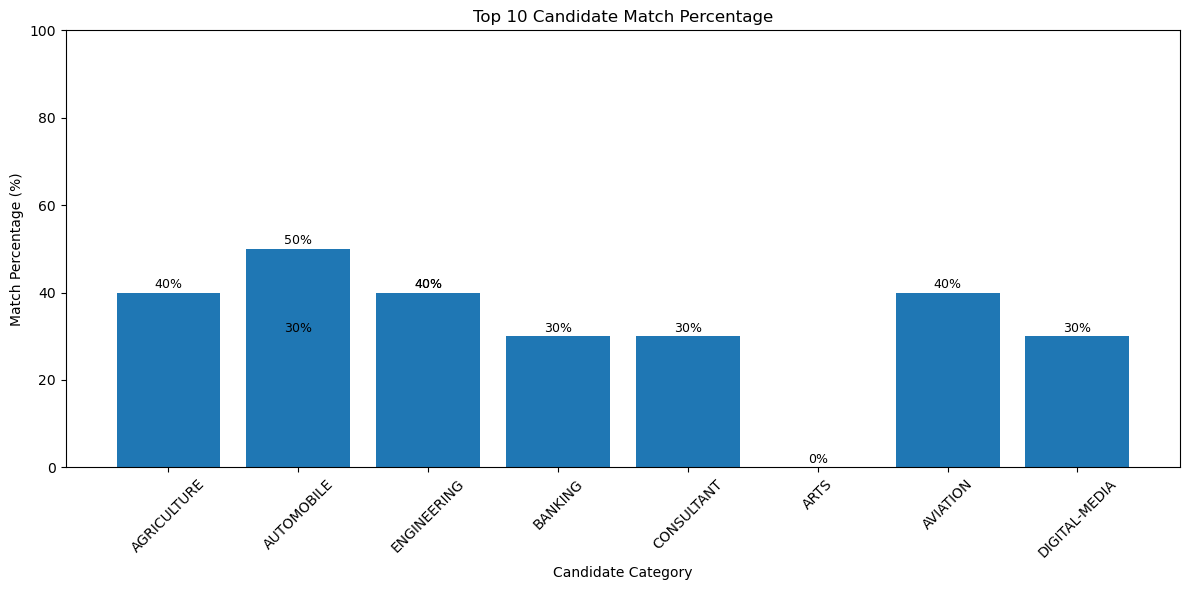

In [30]:
import matplotlib.pyplot as plt

top10 = ranked_df.head(10)

plt.figure(figsize=(12,6))

bars = plt.bar(top10["Category"], top10["Match %"])

plt.title("Top 10 Candidate Match Percentage")
plt.xlabel("Candidate Category")
plt.ylabel("Match Percentage (%)")
plt.xticks(rotation=45)
plt.ylim(0,100)

# Add values above bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 1,
        f"{height:.0f}%",
        ha="center",
        fontsize=9
    )

plt.tight_layout()
plt.show()

In [31]:
ranked_df.to_csv("output/ranked_candidates.csv", index=False)

print("Project completed successfully!")

Project completed successfully!


In [1]:
!pip install pdfplumber pandas scikit-learn nltk matplotlib

In [2]:
import os
import re
import pdfplumber
import pandas as pd
import matplotlib.pyplot as plt
import nltk

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

nltk.download("stopwords")

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lavan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [10]:
import os

print(os.listdir("data"))
print(os.listdir("data/data"))

['.ipynb_checkpoints', 'data', 'job_description.txt', 'resumes.csv']
['.ipynb_checkpoints', 'ACCOUNTANT', 'ADVOCATE', 'AGRICULTURE', 'APPAREL', 'ARTS', 'AUTOMOBILE', 'AVIATION', 'BANKING', 'BPO', 'BUSINESS-DEVELOPMENT', 'CHEF', 'CONSTRUCTION', 'CONSULTANT', 'DESIGNER', 'DIGITAL-MEDIA', 'ENGINEERING', 'FINANCE', 'FITNESS', 'HEALTHCARE', 'HR', 'INFORMATION-TECHNOLOGY', 'PUBLIC-RELATIONS', 'SALES', 'TEACHER']


In [12]:
import os

print(os.listdir("data/data/ACCOUNTANT")[:10])

['10554236.pdf', '10674770.pdf', '11163645.pdf', '11759079.pdf', '12065211.pdf', '12202337.pdf', '12338274.pdf', '12442909.pdf', '12780508.pdf', '12802330.pdf']


In [13]:
import os
import pdfplumber

resume_folder = "data/data"

resume_names = []
resume_texts = []

count = 0

for category in os.listdir(resume_folder):
    category_path = os.path.join(resume_folder, category)

    if os.path.isdir(category_path):
        for file in os.listdir(category_path):
            if file.lower().endswith(".pdf"):

                pdf_path = os.path.join(category_path, file)

                text = ""

                with pdfplumber.open(pdf_path) as pdf:
                    for page in pdf.pages:
                        page_text = page.extract_text()
                        if page_text:
                            text += page_text + "\n"

                resume_names.append(file)
                resume_texts.append(text)

                count += 1

                if count == 20:
                    break

        if count == 20:
            break

print("Total resumes loaded:", len(resume_names))

Total resumes loaded: 20


In [14]:
import re
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-zA-Z ]', ' ', text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

clean_resumes = [clean_text(text) for text in resume_texts]

print("Text cleaning completed!")

Text cleaning completed!


In [16]:
import os

print(os.getcwd())
print(os.listdir())

C:\Users\lavan\Documents\FUTURE_ML_03
['.ipynb_checkpoints', 'data', 'output', 'README.md', 'requirements.txt', 'Resume_Screening.ipynb', 'resume_screening.py', 'screenshots']


In [17]:
with open("data/job_description.txt", "r", encoding="utf-8") as f:
    job_description = f.read()

print(job_description)

Python Machine Learning Developer

Required Skills:
- Python
- Machine Learning
- Pandas
- NumPy
- Scikit-learn
- SQL
- Git
- Data Analysis
- Natural Language Processing (NLP)
- Communication
- Problem Solving


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

vectors = vectorizer.fit_transform(clean_resumes + [job_description])

print("TF-IDF Vectorization Completed!")

TF-IDF Vectorization Completed!


In [19]:
from sklearn.metrics.pairwise import cosine_similarity

scores = cosine_similarity(
    vectors[-1],
    vectors[:-1]
).flatten()

print(scores)

[0.03129105 0.02263556 0.01643355 0.01385958 0.01255038 0.03325732
 0.03016123 0.01621217 0.02219294 0.02759207 0.01284445 0.01089183
 0.02103479 0.015479   0.01391281 0.06076826 0.02071837 0.01477783
 0.04131262 0.01333611]


In [20]:
results = pd.DataFrame({
    "Resume": resume_names,
    "Similarity Score": scores
})

results = results.sort_values(
    by="Similarity Score",
    ascending=False
)

results.head(10)

,Resume,Similarity Score
15,14055988.pdf,0.060768
18,14449423.pdf,0.041313
5,12202337.pdf,0.033257
0,10554236.pdf,0.031291
6,12338274.pdf,0.030161
9,12802330.pdf,0.027592
1,10674770.pdf,0.022636
8,12780508.pdf,0.022193
12,13294301.pdf,0.021035
16,14126433.pdf,0.020718


In [21]:
skills = [
    "python",
    "machine learning",
    "sql",
    "pandas",
    "numpy",
    "scikit",
    "data analysis",
    "communication"
]

def extract_skills(text):
    text = text.lower()
    found = []

    for skill in skills:
        if skill in text:
            found.append(skill)

    return found

results["Skills"] = [extract_skills(text) for text in resume_texts]

results.head()

,Resume,Similarity Score,Skills
15,14055988.pdf,0.060768,[communication]
18,14449423.pdf,0.041313,[]
5,12202337.pdf,0.033257,[communication]
0,10554236.pdf,0.031291,[]
6,12338274.pdf,0.030161,"[sql, communication]"


In [22]:
required_skills = set(skills)

results["Missing Skills"] = results["Skills"].apply(
    lambda x: list(required_skills - set(x))
)

results.head()

,Resume,Similarity Score,Skills,Missing Skills
15,14055988.pdf,0.060768,[communication],"[numpy, scikit, data analysis, python, pandas,..."
18,14449423.pdf,0.041313,[],"[numpy, scikit, communication, data analysis, ..."
5,12202337.pdf,0.033257,[communication],"[numpy, scikit, data analysis, python, pandas,..."
0,10554236.pdf,0.031291,[],"[numpy, scikit, communication, data analysis, ..."
6,12338274.pdf,0.030161,"[sql, communication]","[numpy, scikit, data analysis, python, pandas,..."


In [23]:
print("Top 10 Candidates")

results.head(10)

Top 10 Candidates


,Resume,Similarity Score,Skills,Missing Skills
15,14055988.pdf,0.060768,[communication],"[numpy, scikit, data analysis, python, pandas,..."
18,14449423.pdf,0.041313,[],"[numpy, scikit, communication, data analysis, ..."
5,12202337.pdf,0.033257,[communication],"[numpy, scikit, data analysis, python, pandas,..."
0,10554236.pdf,0.031291,[],"[numpy, scikit, communication, data analysis, ..."
6,12338274.pdf,0.030161,"[sql, communication]","[numpy, scikit, data analysis, python, pandas,..."
9,12802330.pdf,0.027592,[communication],"[numpy, scikit, data analysis, python, pandas,..."
1,10674770.pdf,0.022636,[],"[numpy, scikit, communication, data analysis, ..."
8,12780508.pdf,0.022193,[communication],"[numpy, scikit, data analysis, python, pandas,..."
12,13294301.pdf,0.021035,[communication],"[numpy, scikit, data analysis, python, pandas,..."
16,14126433.pdf,0.020718,[communication],"[numpy, scikit, data analysis, python, pandas,..."


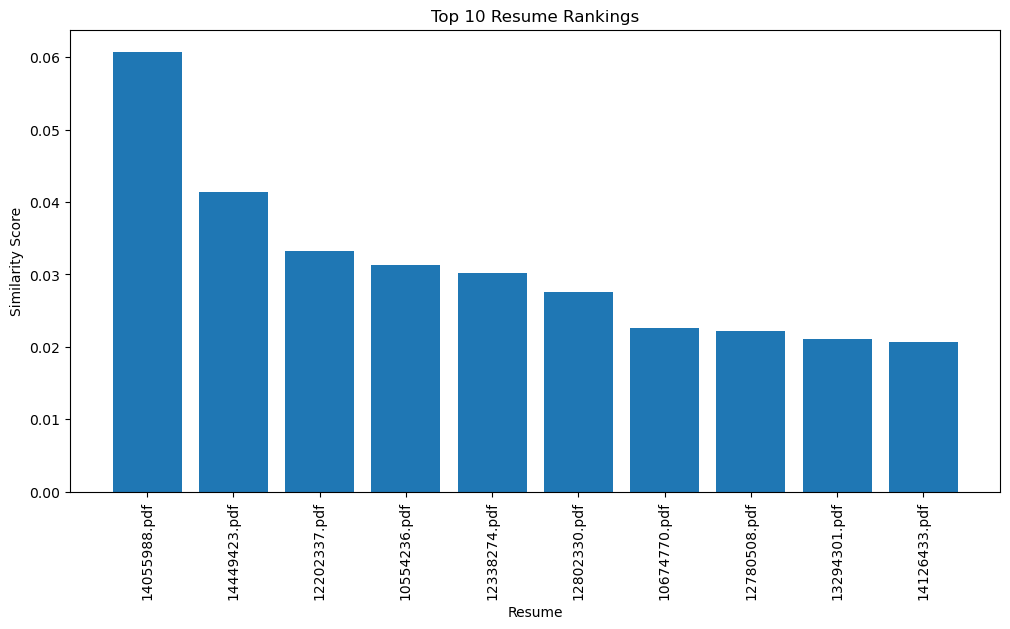

In [24]:
import matplotlib.pyplot as plt

top10 = results.head(10)

plt.figure(figsize=(12,6))
plt.bar(top10["Resume"], top10["Similarity Score"])

plt.xticks(rotation=90)
plt.xlabel("Resume")
plt.ylabel("Similarity Score")
plt.title("Top 10 Resume Rankings")

plt.show()

In [25]:
results.to_csv("Candidate_Ranking.csv", index=False)

print("Candidate_Ranking.csv saved successfully!")

Candidate_Ranking.csv saved successfully!
